In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.1 MB/s eta 0:00:0000:01


In [2]:
from ultralytics import YOLO
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
!ls /kaggle/input

datasets


In [11]:
!ls -R /kaggle/input/datasets/zymzym/neu-yolo

/kaggle/input/datasets/zymzym/neu-yolo:
train  valid  xml2yolo.py

/kaggle/input/datasets/zymzym/neu-yolo/train:
train

/kaggle/input/datasets/zymzym/neu-yolo/train/train:
images	labels	labels.cache

/kaggle/input/datasets/zymzym/neu-yolo/train/train/images:
crazing_100.jpg    patches_100.jpg	   rolled-in_scale_100.jpg
crazing_101.jpg    patches_101.jpg	   rolled-in_scale_101.jpg
crazing_102.jpg    patches_102.jpg	   rolled-in_scale_102.jpg
crazing_103.jpg    patches_103.jpg	   rolled-in_scale_103.jpg
crazing_104.jpg    patches_104.jpg	   rolled-in_scale_104.jpg
crazing_105.jpg    patches_105.jpg	   rolled-in_scale_105.jpg
crazing_106.jpg    patches_106.jpg	   rolled-in_scale_106.jpg
crazing_107.jpg    patches_107.jpg	   rolled-in_scale_107.jpg
crazing_108.jpg    patches_108.jpg	   rolled-in_scale_108.jpg
crazing_109.jpg    patches_109.jpg	   rolled-in_scale_109.jpg
crazing_10.jpg	   patches_10.jpg	   rolled-in_scale_10.jpg
crazing_110.jpg    patches_110.jpg	   rolled-in_scale_110.jpg


In [12]:
yaml_content = """
path: /kaggle/input/datasets/zymzym/neu-yolo

train: train/train/images
val: valid/valid/images

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created!")

data.yaml created!


In [13]:
!cat /kaggle/working/data.yaml


path: /kaggle/input/datasets/zymzym/neu-yolo

train: train/train/images
val: valid/valid/images

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches


In [14]:
model = YOLO("yolov8s.pt")

In [15]:
results = model.train(
    data="/kaggle/working/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    optimizer="AdamW",
    lr0=0.001,
    cache=True,
    cos_lr=True,
    patience=30,
    workers=2,
    project="NEU_Project",
    name="YOLOv8s"
)

Ultralytics 8.4.86 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8s, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=

In [16]:
metrics = model.val()

print("Precision :", metrics.box.mp)
print("Recall :", metrics.box.mr)
print("mAP@50 :", metrics.box.map50)
print("mAP@50-95 :", metrics.box.map)

Ultralytics 8.4.86 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 1.6±0.2 ms, read: 27.9±11.8 MB/s, size: 14.1 KB)
val: Scanning /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 640.5it/s 0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/zymzym/neu-yolo/valid/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.4it/s 0.8s1.1s
                   all         30         64      0.785       0.77      0.818      0.501
               crazing          5          8       0.49      0.242      0.547       0.32
             inclusion          5         15      0.663        0.8      0.699      0.321
               patches          5         17      0.872      0.941       0.98      0.663
 

In [17]:
model.predict(
    source="/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images",
    save=True,
    conf=0.25
)


image 1/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_1.jpg: 640x640 2 crazings, 16.1ms
image 2/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_2.jpg: 640x640 1 crazing, 16.2ms
image 3/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_3.jpg: 640x640 (no detections), 16.1ms
image 4/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_4.jpg: 640x640 2 crazings, 16.2ms
image 5/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_5.jpg: 640x640 1 crazing, 16.1ms
image 6/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_1.jpg: 640x640 4 inclusions, 16.1ms
image 7/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_2.jpg: 640x640 3 inclusions, 16.1ms
image 8/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_3.jpg: 640x640 3 inclusions, 14.2ms
image 9/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_4.jpg: 640x640 3 

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'crazing', 1: 'inclusion', 2: 'patches', 3: 'pitted_surface', 4: 'rolled-in_scale', 5: 'scratches'}
 obb: None
 orig_img: array([[[185, 185, 185],
         [175, 175, 175],
         [171, 171, 171],
         ...,
         [102, 102, 102],
         [ 89,  89,  89],
         [ 84,  84,  84]],
 
        [[169, 169, 169],
         [171, 171, 171],
         [195, 195, 195],
         ...,
         [ 96,  96,  96],
         [ 89,  89,  89],
         [107, 107, 107]],
 
        [[192, 192, 192],
         [222, 222, 222],
         [200, 200, 200],
         ...,
         [ 83,  83,  83],
         [118, 118, 118],
         [112, 112, 112]],
 
        ...,
 
        [[253, 253, 253],
         [219, 219, 219],
         [194, 194, 194],
         ...,
         [164, 164, 164],
         [132, 132, 132],
         [123, 123, 123]],
 
        [[255, 255, 

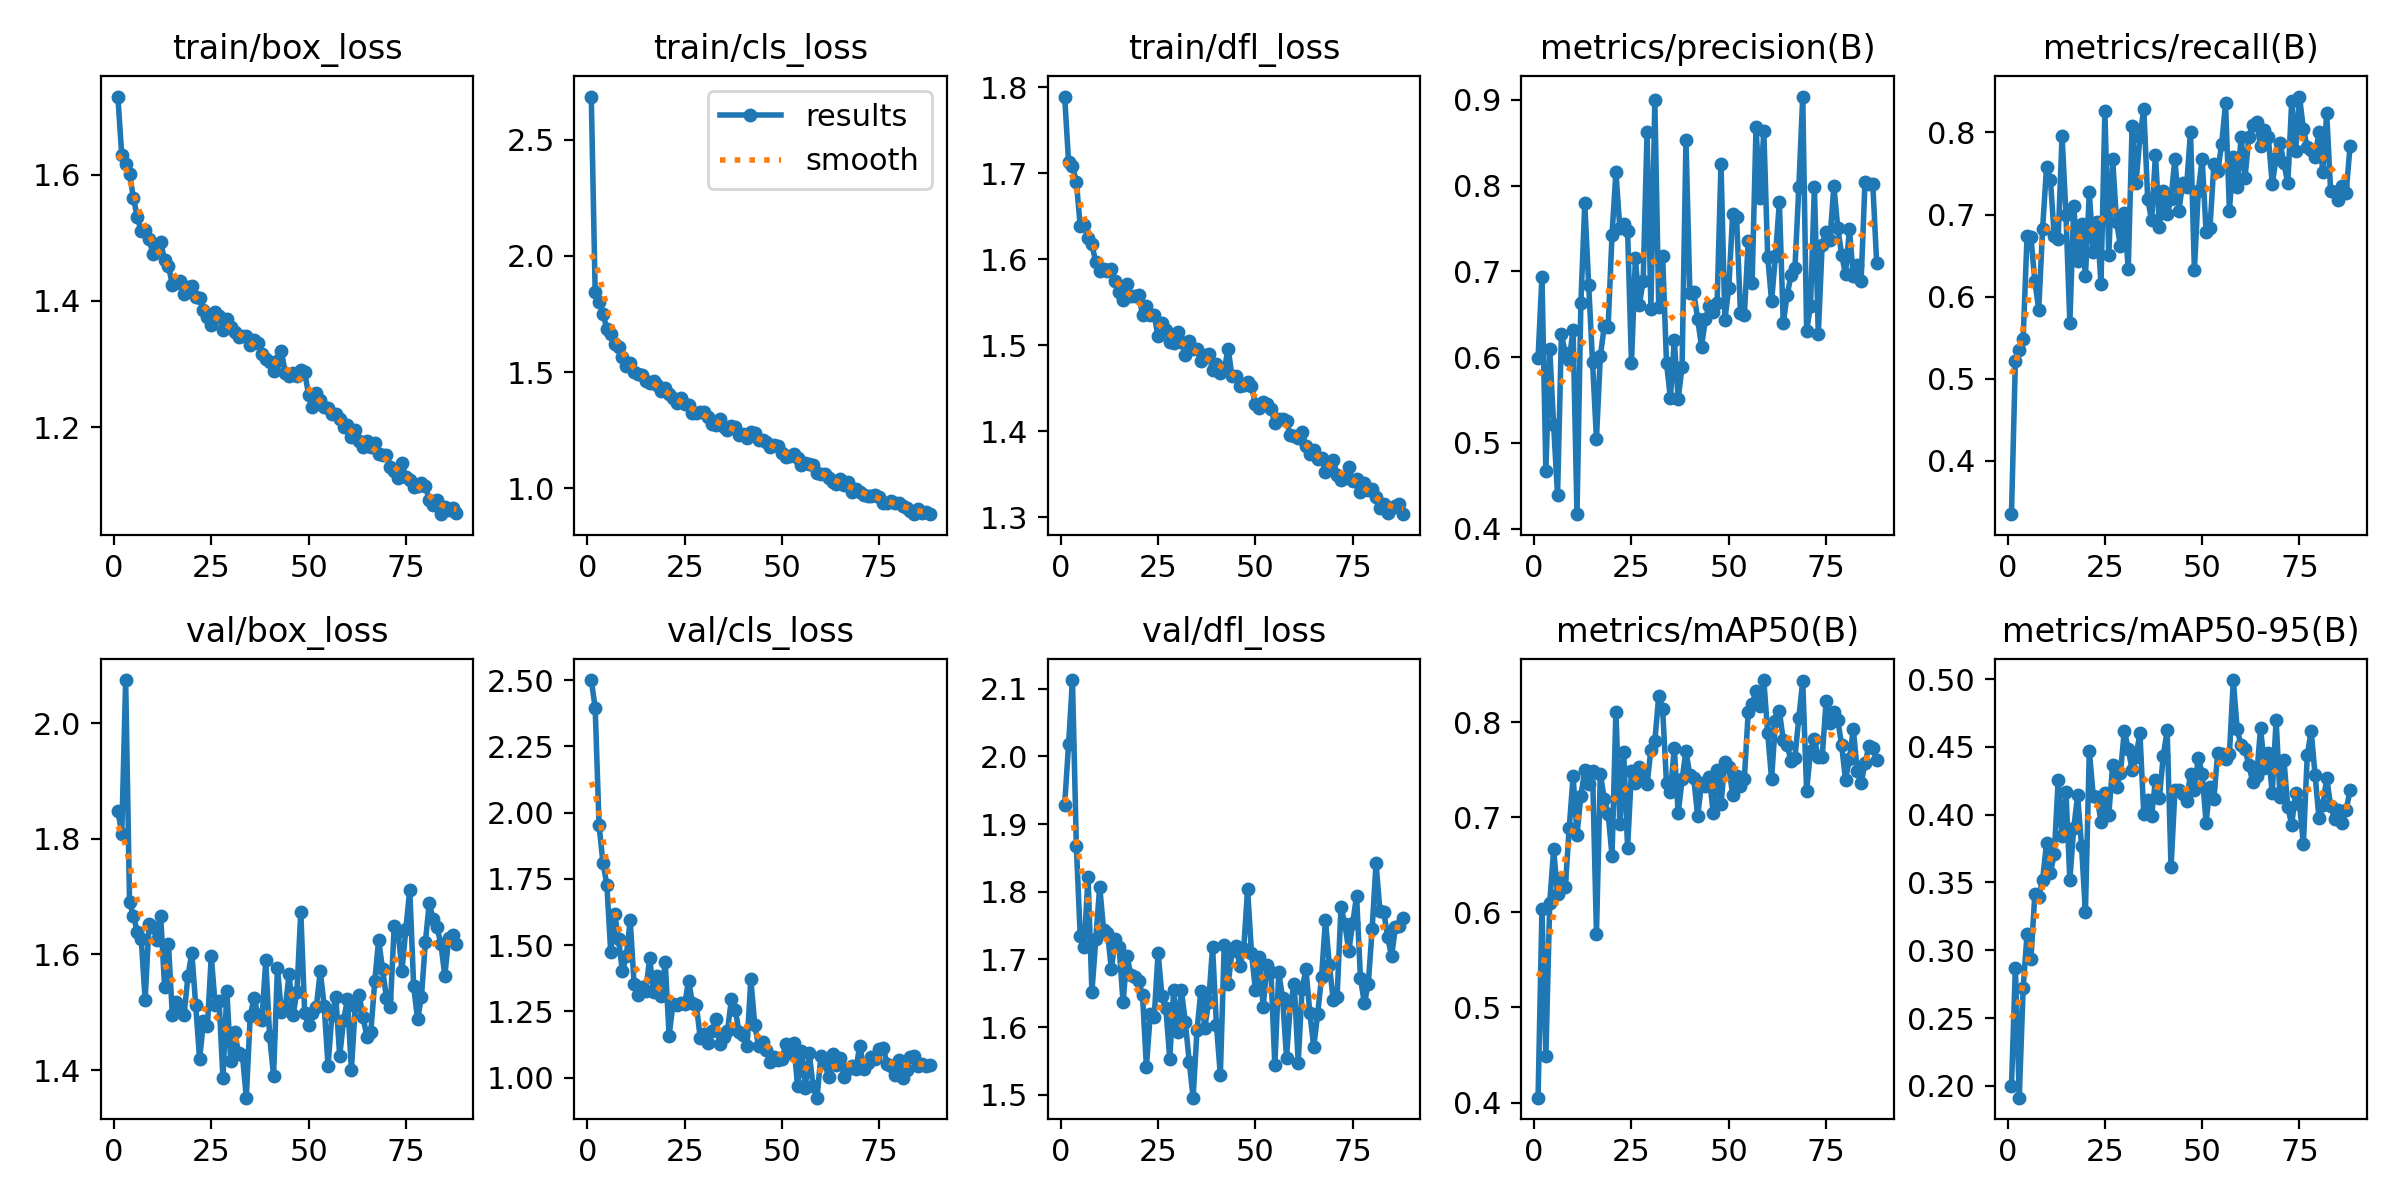

In [21]:
from IPython.display import Image

Image("/kaggle/working/runs/detect/NEU_Project/YOLOv8s/results.png")

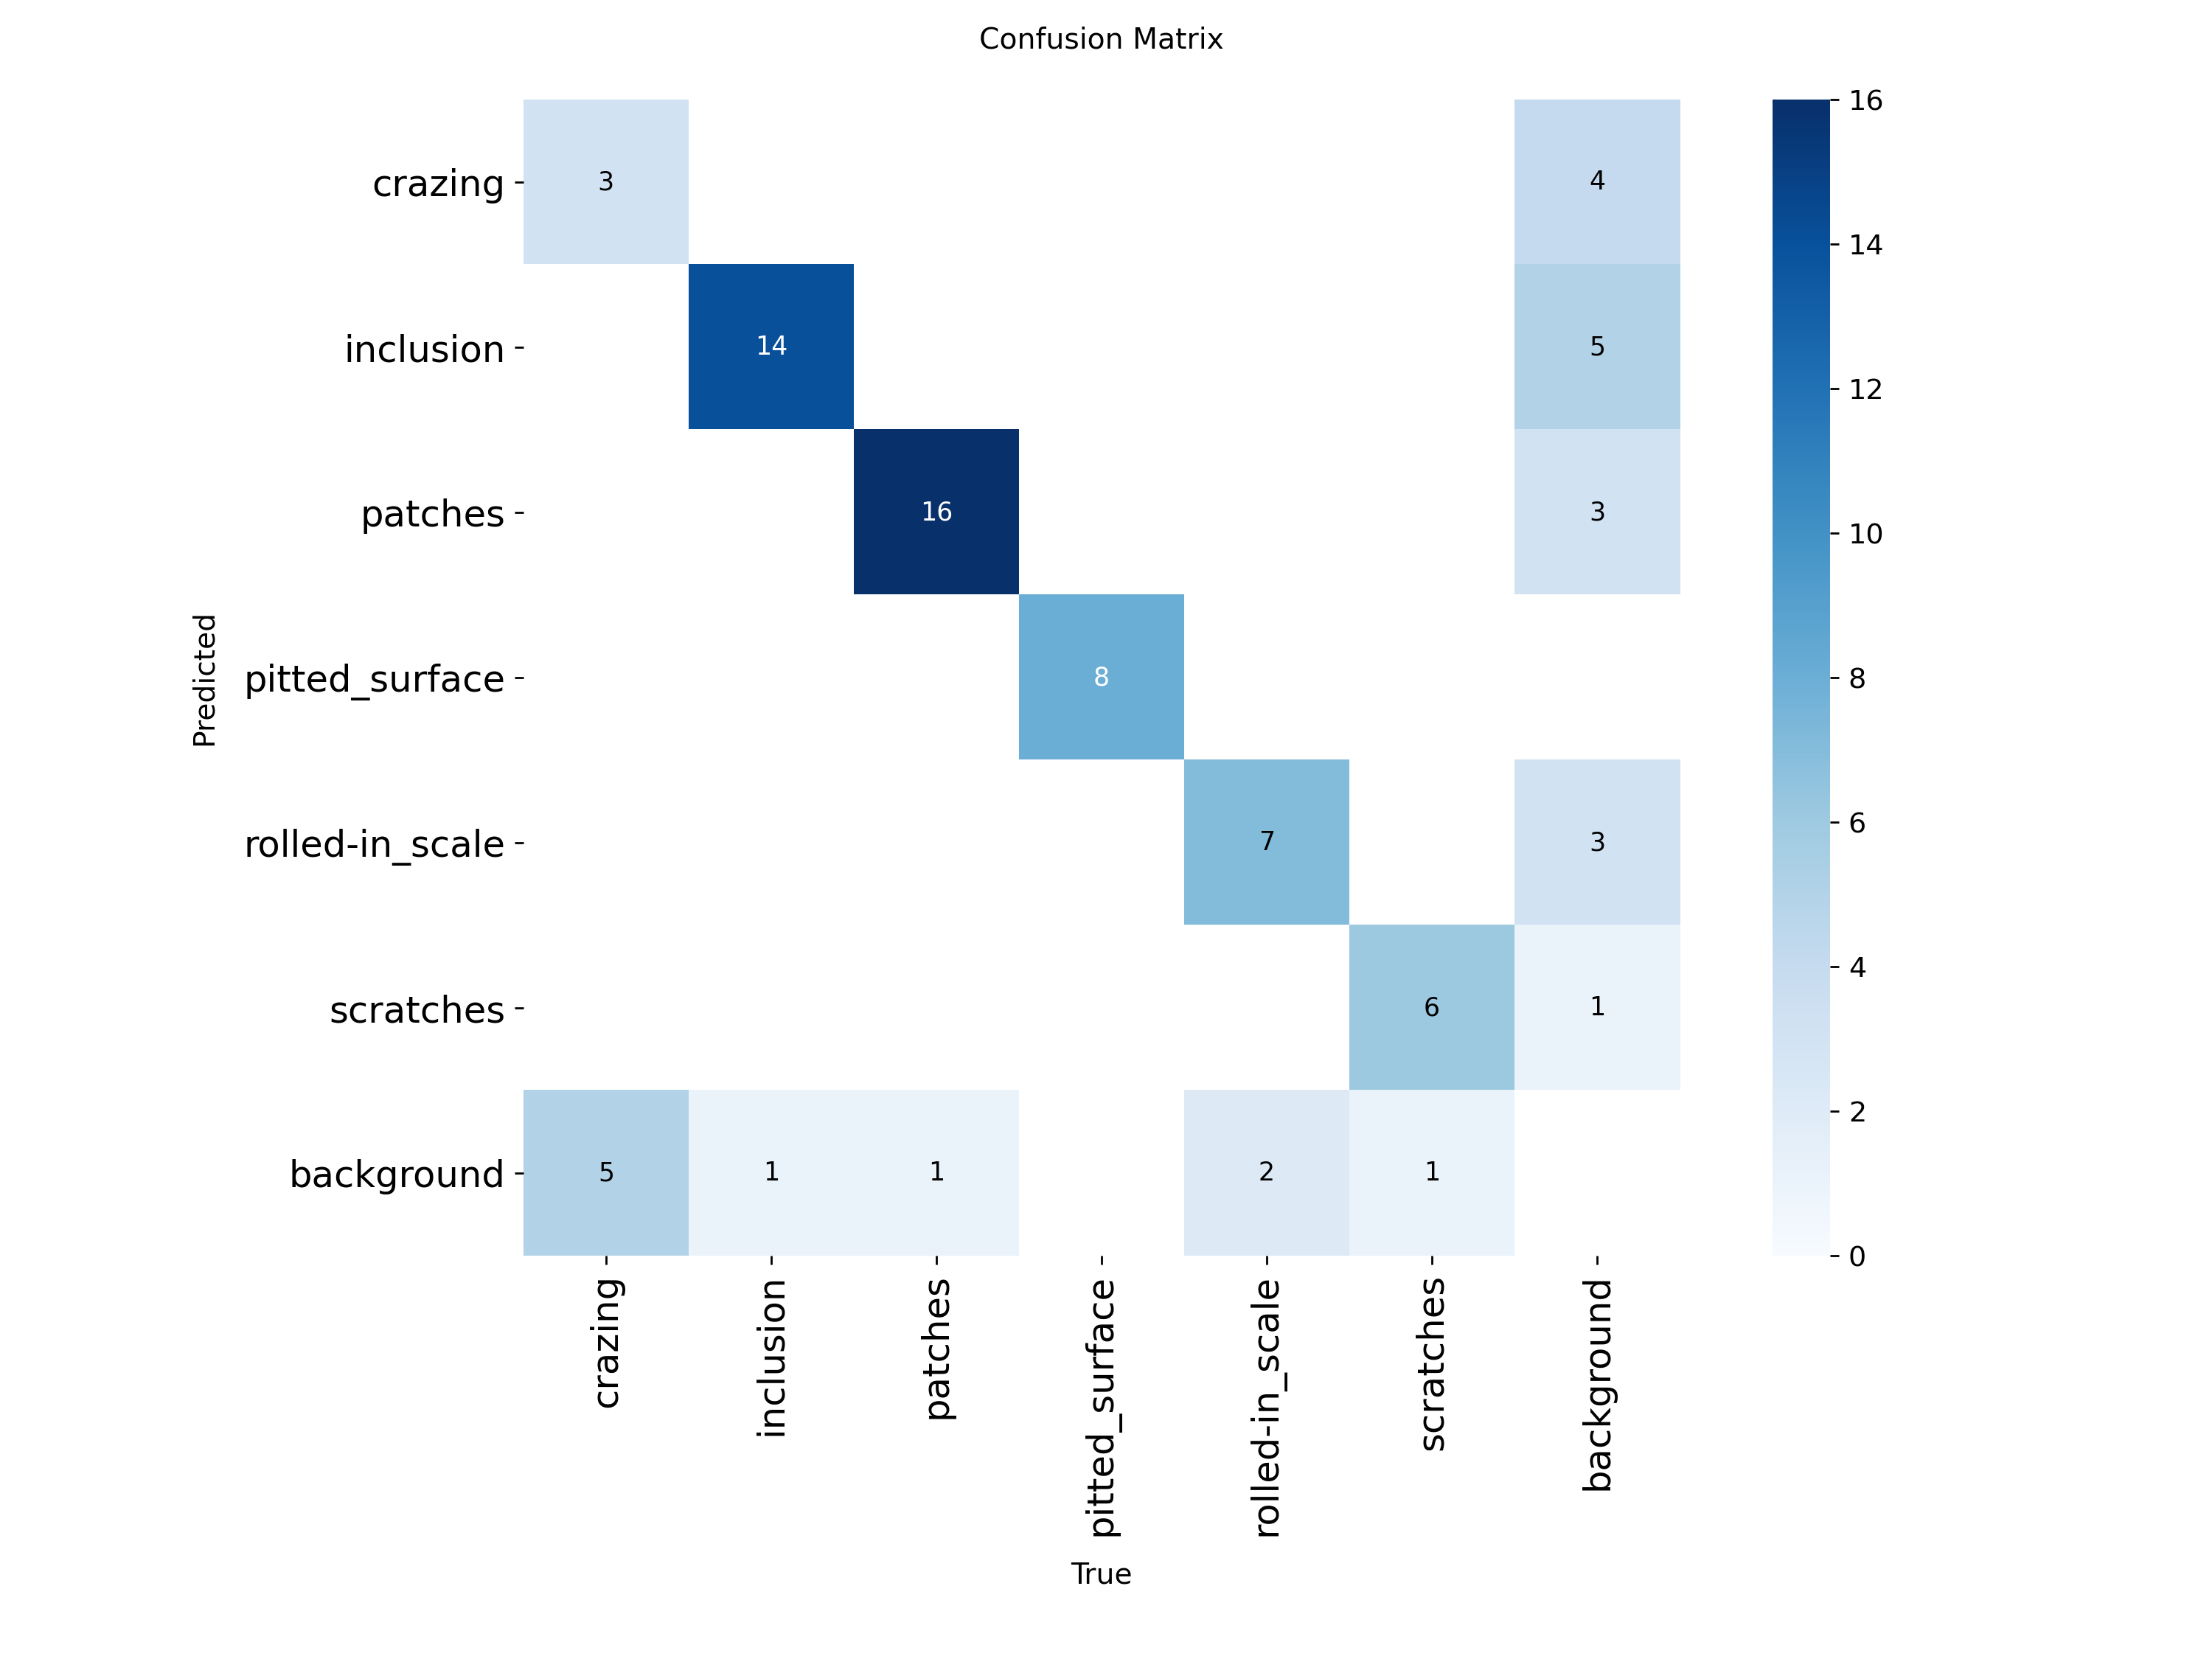

In [22]:
from IPython.display import Image

Image("/kaggle/working/runs/detect/NEU_Project/YOLOv8s/confusion_matrix.png")

In [23]:
metrics = model.val()

print(f"Precision   : {metrics.box.mp:.3f}")
print(f"Recall      : {metrics.box.mr:.3f}")
print(f"mAP@50      : {metrics.box.map50:.3f}")
print(f"mAP@50-95   : {metrics.box.map:.3f}")

Ultralytics 8.4.86 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 2.6±1.8 ms, read: 20.1±12.9 MB/s, size: 11.1 KB)
val: Scanning /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 327.8it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/zymzym/neu-yolo/valid/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.1it/s 0.9s1.6s
                   all         30         64      0.785       0.77      0.818      0.501
               crazing          5          8       0.49      0.242      0.547       0.32
             inclusion          5         15      0.663        0.8      0.699      0.321
               patches          5         17      0.872      0.941       0.98      0.663
        pitted_surface          5          8      0.946          1      0.995      

In [24]:
model.predict(
    source="/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images",
    save=True,
    conf=0.25
)


image 1/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_1.jpg: 640x640 2 crazings, 17.3ms
image 2/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_2.jpg: 640x640 1 crazing, 16.1ms
image 3/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_3.jpg: 640x640 (no detections), 16.1ms
image 4/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_4.jpg: 640x640 2 crazings, 16.2ms
image 5/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_5.jpg: 640x640 1 crazing, 16.2ms
image 6/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_1.jpg: 640x640 4 inclusions, 16.1ms
image 7/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_2.jpg: 640x640 3 inclusions, 14.4ms
image 8/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_3.jpg: 640x640 3 inclusions, 13.1ms
image 9/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_4.jpg: 640x640 3 

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'crazing', 1: 'inclusion', 2: 'patches', 3: 'pitted_surface', 4: 'rolled-in_scale', 5: 'scratches'}
 obb: None
 orig_img: array([[[185, 185, 185],
         [175, 175, 175],
         [171, 171, 171],
         ...,
         [102, 102, 102],
         [ 89,  89,  89],
         [ 84,  84,  84]],
 
        [[169, 169, 169],
         [171, 171, 171],
         [195, 195, 195],
         ...,
         [ 96,  96,  96],
         [ 89,  89,  89],
         [107, 107, 107]],
 
        [[192, 192, 192],
         [222, 222, 222],
         [200, 200, 200],
         ...,
         [ 83,  83,  83],
         [118, 118, 118],
         [112, 112, 112]],
 
        ...,
 
        [[253, 253, 253],
         [219, 219, 219],
         [194, 194, 194],
         ...,
         [164, 164, 164],
         [132, 132, 132],
         [123, 123, 123]],
 
        [[255, 255, 

In [25]:
import glob
from IPython.display import Image

preds = glob.glob("/kaggle/working/runs/detect/predict/*.jpg")

print(preds)

['/kaggle/working/runs/detect/predict/crazing_2.jpg', '/kaggle/working/runs/detect/predict/scratches_2.jpg', '/kaggle/working/runs/detect/predict/pitted_surface_4.jpg', '/kaggle/working/runs/detect/predict/pitted_surface_1.jpg', '/kaggle/working/runs/detect/predict/patches_4.jpg', '/kaggle/working/runs/detect/predict/inclusion_3.jpg', '/kaggle/working/runs/detect/predict/crazing_4.jpg', '/kaggle/working/runs/detect/predict/rolled-in_scale_1.jpg', '/kaggle/working/runs/detect/predict/inclusion_4.jpg', '/kaggle/working/runs/detect/predict/scratches_3.jpg', '/kaggle/working/runs/detect/predict/pitted_surface_3.jpg', '/kaggle/working/runs/detect/predict/patches_3.jpg', '/kaggle/working/runs/detect/predict/inclusion_5.jpg', '/kaggle/working/runs/detect/predict/inclusion_2.jpg', '/kaggle/working/runs/detect/predict/inclusion_1.jpg', '/kaggle/working/runs/detect/predict/crazing_5.jpg', '/kaggle/working/runs/detect/predict/rolled-in_scale_4.jpg', '/kaggle/working/runs/detect/predict/scratches_

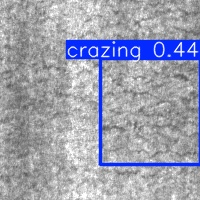

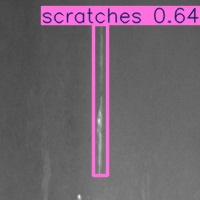

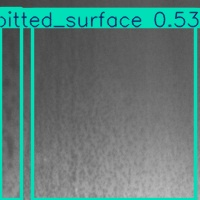

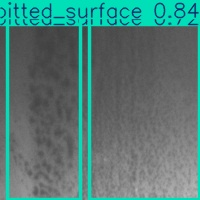

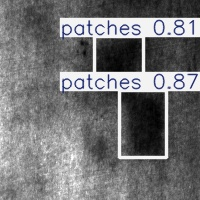

In [28]:
from IPython.display import Image, display

for img in preds[:5]:
    display(Image(filename=img))